# ✅ Logistic Regression , k-NN, SVM 모델을 이용한 분류문제

- 다양한 모델을 반복문으로 한 번에 처리할 수 있도록 리스트에 모델들을 담아 순회하는 방식으로 코드를 작성.

- Scikit-learn의 Pipeline은 '스케일러 + 모델 A'처럼 하나의 흐름을 정의하고,
- 리스트에 각 모델 객체(혹은 파이프라인 객체)를 담아 루프를 돌리는 방식.

  - 중복 제거: 스케일러 정의와 학습(fit), 예측(predict) 과정을 모델마다 따로 적지 않고 for 루프 하나로 묶어 코드 양을 줄이기.

  - 유연한 확장성: 나중에 서포트 벡터 머신(SVM)이나 결정 트리(Decision Tree) 같은 새로운 분류 모델을 추가하고 싶다면, models 리스트에 추가

  - 조건부 속성 접근: k-NN 알고리즘에는 가중치(w)나 절편(b) 개념이 없으므로, if 조건문을 활용해 로지스틱 회귀일 때만 해당 속성을 출력하도록 예외 처리를 하기


# ✅  [분류문제 웹서비스 배포]
- 다양한 분류 모델를 웹에서 직접 확인하고 테스트할 수 있도록 Streamlit 애플리케이션으로 전환하고, pyngrok을 이용해 외부에서 접속 가능한 임시 URL로 배포하는 전체 과정

- 요구사항
  - 모델 및 기준값을 파일(.pkl)로 저장 및 로드,
  - %%writefile app.py 웹 소스 활용,
  - 구글 코랩 환경을 고려한 ngrok 터널링 최적화을 반영

### 1 단계: 필수 라이브러리 설치


In [ ]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 80.5 MB/s eta 0:00:00


### 2단계: 모델 학습 및 파일(.pkl) 저장
- 데이터를 준비 및 통합
  - 닥스훈트와 진돗개의 길이·높이 데이터를 생성하고 하나의 데이터셋으로 통합,
- 파이프라인 모델들을 학습시킨 뒤
- joblib 라이브러리를 사용하여 저장.
- 추가 요구사항
  
  -  가상 데이터 증강(Augmentation),
     - 현재 원본 데이터가 총 16개로 매우 적기 때문에, 그대로 분리하면 평가가 불가능.
     - 따라서 기존 데이터의 통계적 특성(평균과 표준편차)에 기반하여 정규분포 노이즈를 섞어 데이터를 총 200개로 증강한 뒤 견고하게 모델을 구축하도록 설계.
  
  -  학습 데이터(Train)와 테스트 데이터(Test) 분리,
  
  -  다중 평가지표(Accuracy, Precision, Recall, F1-score, Confusion Matrix)

  - 분류 결과 리포트로 출력(classificaltoon report)
  
  -  GridSearchCV + 최적 K-Fold 튜닝을 모두 반영한 완성형 머신러닝 파이프라인 코드를 작성.


   


In [ ]:
import numpy as np  # 수치 연산 및 배열 처리를 위한 라이브러리
import joblib  # 학습된 모델 및 데이터를 파일로 저장/로드
from sklearn.pipeline import Pipeline  # 데이터 전처리와 모델 학습 과정을 하나로 묶어주는 파이프라인
from sklearn.preprocessing import StandardScaler  # 데이터의 특성(Feature) 스케일을 평균 0, 분산 1로 맞추는 표준화 도구
from sklearn.linear_model import LogisticRegression  # 선형 분류 알고리즘인 로지스틱 회귀 모델
from sklearn.neighbors import KNeighborsClassifier  # 주변 이웃 데이터를 기반으로 분류하는 k-NN 모델
from sklearn.svm import SVC  # 결정 경계면과 마진을 이용해 분류하는 서포트 벡터 머신(SVM) 모델
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV  # 데이터 분할, 교차 검증, 하이퍼파라미터 튜닝 도구
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report  # 모델 성능 평가 지표 함수들

# ============================================================
# 1. 원본 데이터 정의 및 가상 데이터 증강 (Data Augmentation)
# ============================================================
# 1-1. 원본 데이터 정의 (닥스훈트: 0, 진돗개: 1)
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]  # 닥스훈트의 몸 길이 데이터
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]  # 닥스훈트의 몸 높이 데이터
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]  # 진돗개의 몸 길이 데이터
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]  # 진돗개의 몸 높이 데이터

d_data_orig = np.column_stack((dach_length, dach_height))  # 닥스훈트의 길이와 높이를 2차원 좌표 배열[(길이, 높이)]로 결합
j_data_orig = np.column_stack((jin_length, jin_height))  # 진돗개의 길이와 높이를 2차원 좌표 배열[(길이, 높이)]로 결합

# 1-2. 데이터 증강 함수 정의 (가우시안 노이즈 추가)
def augment_data(orig_data, target_count=100, noise_level=2.0, random_state=42):
    np.random.seed(random_state)  # 무작위 결과의 재현성을 위해 무작위수 생성 시드 고정

    augmented = []  # 생성된 증강 데이터를 담을 빈 리스트 생성
    for _ in range(target_count):  # 목표 데이터 개수(100개)만큼 반복 실행
        idx = np.random.choice(len(orig_data))  # 원본 데이터(8개) 중 무작위로 하나의 인덱스 선택
        # 오분류율을 높이기 위해 변동 폭이 큰 가우시안 노이즈(평균 0, 표준편차 noise_level) 생성
        noise = np.random.normal(0, noise_level, size=2)
        augmented.append(orig_data[idx] + noise)  # 선택한 원본 데이터에 노이즈를 더해 리스트에 추가

    return np.array(augmented)  # 파이썬 리스트를 넘파이 배열로 변환하여 반환

# 각 클래스별 100개씩 총 200개로 데이터 증강 실행
# 오분류율 유도를 위해 noise_level을 6.5로 대폭 높여 두 클래스 분포의 경계면이 겹치도록 설정
X_dach_aug = augment_data(d_data_orig, target_count=100, noise_level=6.5, random_state=42)  # 닥스훈트 가상 데이터 100개 생성
y_dach_aug = np.zeros(len(X_dach_aug))  # 닥스훈트 데이터의 정답 레이블을 0으로 채움

X_jin_aug = augment_data(j_data_orig, target_count=100, noise_level=6.5, random_state=100)  # 진돗개 가상 데이터 100개 생성
y_jin_aug = np.ones(len(X_jin_aug))  # 진돗개 데이터의 정답 레이블을 1으로 채움

# 증강 데이터 병합 및 메타데이터 정의
X_augmented = np.concatenate((X_dach_aug, X_jin_aug))  # 두 견종의 특징 데이터(X)를 하나로 병합 (총 200행)
y_augmented = np.concatenate((y_dach_aug, y_jin_aug))  # 두 견종의 정답 데이터(y)를 하나로 병합 (총 200개)
dog_classes = {0: '닥스훈트', 1: '진돗개'}  # 숫자 정답 레이블을 실제 문자로 매핑할 딕셔너리 정의

print(f"📊 데이터 증강 완료: 전체 데이터 수 {X_augmented.shape[0]}개")

# =====================================================
# 2. 학습 데이터(Train) 및 테스트 데이터(Test) 분리
# =====================================================
# 전체 데이터를 8:2 비율로 분할, 클래스 비율을 동일하게 유지하기 위해 stratify=y_augmented 지정
X_train, X_test, y_train, y_test = train_test_split(
    X_augmented, y_augmented, test_size=0.2, random_state=42, stratify=y_augmented
)

print(f"📈 데이터 분할 완료: 학습용 {X_train.shape[0]}개, 검증(테스트)용 {X_test.shape[0]}개")

# ======================================================
# 3. 기본 파이프라인 및 하이퍼파라미터 그리드 정의
# ======================================================
# StandardScaler 전처리와 각 분류 모델을 결합한 파이프라인 딕셔너리 정의
pipelines = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(random_state=42))]),
    "k-Nearest Neighbors (k-NN)": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
    "Support Vector Machine (SVM)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(probability=True, random_state=42))])
}

# GridSearchCV를 통해 탐색할 각 모델별 하이퍼파라미터 후보리스트 정의
param_grids = {
    "Logistic Regression": {
        "clf__C": [0.1, 1.0, 10.0],  # 규제 강도의 후보리스트
        "clf__penalty": ['l2']  # L2 릿지 규제 사용
    },
    "k-Nearest Neighbors (k-NN)": {
        "clf__n_neighbors": [3, 5, 7, 9],  # 살펴볼 주변 이웃의 개수 후보리스트
        "clf__weights": ['uniform', 'distance']  # 가중치 부여 방식 후보리스트
    },
    "Support Vector Machine (SVM)": [  # 커널별 불필요한 경고를 방지하기 위해 리스트 내 딕셔너리로 분리 정의
        {
            "clf__C": [0.1, 1.0, 10.0],  # 선형 커널용 마진 규제 강도 후보리스트
            "clf__kernel": ['linear']
        },
        {
            "clf__C": [0.1, 1.0, 10.0],  # RBF 커널용 마진 규제 강도 후보리스트
            "clf__kernel": ['rbf'],
            "clf__gamma": [0.01, 0.1, 1.0, 'scale']  # RBF 커널용 곡률 파라미터 후보리스트
        }
    ]
}

# =========================================================
# 4. GridSearch + K-Fold 학습 최적화 (Train Data 활용)
# =========================================================
k_candidates = [3, 4, 5]  # 교차 검증에 사용할 K(폴드 수)의 후보리스트 설정
best_models = {}  # 최적화가 완료된 모델 객체를 저장할 빈 딕셔너리
evaluation_summary = {}  # 모델별 최종 성능 지표 점수를 기록할 빈 딕셔너리

print("\n" + "="*100)
print(" 🚀 GridSearchCV 기반 하이퍼파라미터 및 K-Fold 최적화 시작")
print("="*100)

# 정의한 3개의 모델(알고리즘) 순서대로 최적화 루프 실행
for name in pipelines.keys():
    best_k_for_model = None  # 가장 높은 점수를 얻은 K값을 저장할 변수 초기화
    best_cv_score = -1  # 가장 높은 교차 검증 점수를 저장할 변수 초기화 (-1로 시작)
    best_search_obj = None  # 가장 우수한 성능을 낸 GridSearchCV 객체를 저장할 변수 초기화

    # 각 K값 후보(3, 4, 5)를 순회하며 최적의 분할 구조 탐색
    for k in k_candidates:
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)  # 정답 비율을 유지하는 K-Fold 분할기 생성
        grid_search = GridSearchCV(
            estimator=pipelines[name],  # 학습할 모델 파이프라인 지정
            param_grid=param_grids[name],  # 하이퍼파라미터 후보 지정
            cv=cv,  # 위에서 생성한 K-Fold 분할 구조 적용
            scoring='accuracy',  # 최적 파라미터 판단의 기준으로 '정확도' 사용
        )
        grid_search.fit(X_train, y_train)  # 학습 데이터(X_train, y_train)를 사용해 그리드 서치 수행

        # 현재 K값에서의 최고 교차 검증 점수가 기존 최고 점수보다 높다면 정보 업데이트
        if grid_search.best_score_ > best_cv_score:
            best_cv_score = grid_search.best_score_  # 최고 점수 업데이트
            best_k_for_model = k  # 최고 점수를 기록한 K값 저장
            best_search_obj = grid_search  # 최고 성능을 낸 그리드 서치 객체 저장


    # 내부 루프 완료 후 최종 선택된 최적 모델 및 하이퍼파라미터 추출
    best_estimator = best_search_obj.best_estimator_  # 최적의 가중치가 학습 완료된 최종 모델 객체
    best_params = best_search_obj.best_params_  # 선택된 최고의 하이퍼파라미터 조합

    # 학습에 한 번도 사용되지 않은 독립된 테스트 데이터(X_test)로 최종 예측 수행
    y_pred = best_estimator.predict(X_test)

    # 평가 지표 산출 함수 호출
    acc = accuracy_score(y_test, y_pred)  # 전체 예측 중 정답을 맞춘 비율 (정확도)
    prec = precision_score(y_test, y_pred)  # 진돗개라고 예측한 것 중 진짜 진돗개인 비율 (정밀도)
    rec = recall_score(y_test, y_pred)  # 실제 진돗개 중 진돗개라고 맞춘 비율 (재현율)
    f1 = f1_score(y_test, y_pred)  # 정밀도와 재현율의 조화 평균 점수 (F1-Score)
    cm = confusion_matrix(y_test, y_pred)  # 예측 결과를 [실제값 vs 예측값] 행렬 형태로 나타낸 오차 행렬

    # 배포 단계를 위해 결과 저장
    best_models[name] = best_estimator  # 저장용 딕셔너리에 최적화된 모델 등록
    evaluation_summary[name] = {  # 성능 요약 딕셔너리에 결과 값 기록
        "best_k": best_k_for_model,
        "best_params": best_params,
        "test_accuracy": acc,
        "test_precision": prec,
        "test_recall": rec,
        "test_f1_score": f1,
        "confusion_matrix": cm.tolist()  # 넘파이 배열인 오차행렬을 pkl 저장이 용이하게 일반 리스트로 변환
    }

    # 결과 화면 출력
    print(f"\n✅ [{name}] 최적화 결과")
    print(f"   - 선택된 최적의 구조       : {best_k_for_model}-Fold CV")
    print(f"   - 선택된 최적 하이퍼파라미터: {best_params}")
    print(f"   -------------------------------------------------")
    print(f" ✅   [최종 테스트 데이터 평가 점수 (Unseen Data)]")
    print(f"   - Accuracy  (정확도) : {acc:.4f}")
    print(f"   - Precision (정밀도) : {prec:.4f}")
    print(f"   - Recall    (재현율) : {rec:.4f}")
    print(f"   - F1-Score  (F1점수) : {f1:.4f}")
    print(f"   - 오차 행렬 (Confusion Matrix) :\n{cm}")
    print("\n ✅   [상세 분류 리포트]")
    # 실제 정답(y_test)와 예측값(y_pred)을 바탕으로 클래스별 정밀도, 재현율, F1점수를 가독성 있게 출력
    print(classification_report(y_test, y_pred, target_names=list(dog_classes.values())))
    print("-" * 100)

# ==========================================
# 5. 최종 결과 모델 및 메타데이터 저장
# ==========================================
# 대시보드(예: Streamlit 앱)에서 그대로 가져다 쓸 수 있도록 패키징)
payload = {
    "models": best_models,  # 3개의 최종 최적화 모델 객체
    "cv_results": evaluation_summary,  # 각 모델들의 테스트 평가 성적표
    "dog_classes": dog_classes,  # 클래스 매핑용 딕셔너리 정보
    "X_data": X_augmented,  # 전체 특징 데이터 배열
    "y_data": y_augmented  # 전체 정답 레이블 배열
}

joblib.dump(payload, "dog_classifier_models.pkl")  # 지정한 파일명("dog_classifier_models.pkl")으로 바이너리 저장 실행
print("\n✅ 모델 분류기 ML 프로세스가 완벽히 완료되었습니다.")
print("   'dog_classifier_models.pkl' 파일에 새 데이터가 저장되었습니다.")

📊 데이터 증강 완료: 전체 데이터 수 200개
📈 데이터 분할 완료: 학습용 160개, 검증(테스트)용 40개

 🚀 GridSearchCV 기반 하이퍼파라미터 및 K-Fold 최적화 시작

✅ [Logistic Regression] 최적화 결과
   - 선택된 최적의 구조       : 3-Fold CV
   - 선택된 최적 하이퍼파라미터: {'clf__C': 1.0, 'clf__penalty': 'l2'}
   -------------------------------------------------
 ✅   [최종 테스트 데이터 평가 점수 (Unseen Data)]
   - Accuracy  (정확도) : 0.9000
   - Precision (정밀도) : 0.9000
   - Recall    (재현율) : 0.9000
   - F1-Score  (F1점수) : 0.9000
   - 오차 행렬 (Confusion Matrix) :
[[18  2]
 [ 2 18]]

 ✅   [상세 분류 리포트]
              precision    recall  f1-score   support

        닥스훈트       0.90      0.90      0.90        20
         진돗개       0.90      0.90      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40

----------------------------------------------------------------------------------------------------

✅ [k-Nearest Neighbors (k-NN)] 최적화 결과
   - 선택된 최적의 구조     

### 3 단계: Streamlit 앱 파일 생성 (%%writefile app.py)
- 파일(.pkl)을 읽어와 화면에 결과를 띄워주는 app.py 웹 애플리케이션 코드 생성.

In [ ]:
%%writefile app.py
# 라이브러리 임포트: 웹 UI, 수치 연산, 모델 로드, 데이터 가공을 위한 핵심 패키지들
import streamlit as st  # Streamlit 웹 어플리케이션 제작
import numpy as np      # 다차원 배열 연산 및 데이터 형태 변환
import joblib           # 학습된 머신러닝 모델(.pkl 파일)을 디스크에서 불러오기
import pandas as pd     # 표 형태의 데이터를 다루고 테이블 UI를 생성

# 웹 브라우저의 페이지 제목과 레이아웃(와이드 모드)을 설정
st.set_page_config(page_title="견종 분류 파이프라인 모델", layout="wide")

# 웹 대시보드 최상단에 큰 메인 제목 출력
st.title("🐕 닥스훈트 vs 진돗개 분류 예측 및 웹 대시보드")

# 대시보드의 목적과 사용된 알고리즘 구조에 대한 간략한 설명
st.write("학습 및 검증(GridSearchCV)이 완료된 로지스틱 회귀, k-NN, SVM 모델을 기반으로 다중 성능 지표를 분석하고 실시간 예측을 수행합니다.")

# 화면을 깔끔하게 분리해 주는 가로 구분선 삽입
st.markdown("---")

# ==========================================
# 1. 파일에서 저장된 모델 및 메타데이터 로드
# ==========================================
def load_classifier_data():
    try:
        # joblib를 이용해 사전 학습된 모델 객체와 성능 지표가 담긴 딕셔너리 파일을 로드
        data = joblib.load("dog_classifier_models.pkl")
        return data  # 불러오기 성공 시 데이터 반환
    except FileNotFoundError:
        # 만약 해당 경로에 파일이 없다면 사용자에게 경고 메시지를 출력
        st.error("⚠️ 'dog_classifier_models.pkl' 파일이 존재하지 않습니다. 먼저 모델 학습 코드를 실행해 주세요!")
        return None  # 실패 시 빈 값 반환

# 선언한 함수를 호출하여 변수에 머신러닝 데이터 패키지(payload)를 할당
payload = load_classifier_data()

# 데이터 로드가 정상적으로 완료되었을 때만 하위 대시보드 로직 실행
if payload is not None:
    models = payload["models"]                # 딕셔너리에서 추출: 최적 하이퍼파라미터로 훈련이 완료된 Pipeline 모델들
    cv_results = payload["cv_results"]        # 딕셔너리에서 추출: GridSearchCV 학습 결과 혼동행렬 및 다중 평가지표
    dog_classes = payload["dog_classes"]      # 딕셔너리에서 추출: 클래스 레이블 맵핑 정보 {0: '닥스훈트', 1: '진돗개'}

    # ==============================================================
    # 2. 대시보드 영역: 모델별 검증 성능 평가 통합 비교 (위쪽 배치)
    # ==============================================================
    # 독립 평가 데이터셋 기준의 종합 성적표 제목 출력
    st.subheader("📊 독립된 검증 데이터(Test Data) 기반 종합 성능 비교")

    # Streamlit 표(Dataframe) 형태로 시각화하기 위해 빈 리스트를 만들고 데이터 재가공 시작
    summary_data = []
    # cv_results 내부를 돌며 모델명과 해당 모델의 스코어 정보들을 하나씩 꺼냄
    for model_name, info in cv_results.items():
        # 데이터프레임의 행 리스트에 딕셔너리 형태로 정렬된 평가지표를 추가
        summary_data.append({
            "모델명": model_name,  # 'Logistic Regression', 'k-NN', 'SVM'
            "최적 CV 구조": f"{info['best_k']}-Fold",  # 학습 때 사용된 StratifiedKFold 분할 수
            "Test Accuracy (정확도)": f"{info['test_accuracy']:.2%}",  # 소수점 둘째 자리 퍼센트 변환
            "Test Precision (정밀도)": f"{info['test_precision']:.2%}",  # 정밀도 퍼센트 변환
            "Test Recall (재현율)": f"{info['test_recall']:.2%}",  # 재현율 퍼센트 변환
            "Test F1-Score": f"{info['test_f1_score']:.4f}"  # F1-Score는 소수점 4자리 실수 표기
        })
    # 가공된 리스트 데이터셋을 판다스 데이터프레임 구조로 최종 변환
    df_summary = pd.DataFrame(summary_data)
    # 웹 화면 전체 너비를 활용하고, 좌측 인덱스 열을 숨긴 채 깔끔한 테이블 형태로 대시보드에 표시
    st.dataframe(df_summary, use_container_width=True, hide_index=True)
    # 상단 종합 성적표와 하단 실시간 예측 영역을 구분하는 가로 선 삽입
    st.markdown("---")

    # ==========================================
    # 3. 사용자 입력 UI (사이드바)
    # ==========================================
    # 왼쪽 사이드바 영역에 입력용 헤더 텍스트 출력
    st.sidebar.header("📋 새로운 데이터 입력")
    # 사용자가 개의 몸통 길이을 조정할 수 있는 숫자 입력 필드 생성 (최소 10, 최대 100, 기본값 59)
    input_length = st.sidebar.number_input("개의 길이 (cm)", min_value=10, max_value=100, value=59)
    # 사용자가 개의 몸통 높이를 조정할 수 있는 숫자 입력 필드 생성 (최소 10, 최대 100, 기본값 35)
    input_height = st.sidebar.number_input("개의 높이 (cm)", min_value=10, max_value=100, value=35)

    # Scikit-learn 모델의 입력 규격에 맞춰 1차원 데이터 값들을 [[길이, 높이]] 형태의 2차원 넘파이 행렬로 묶음
    newdata = np.array([[input_length, input_height]])

    # ===================================================
    # 4. 실시간 예측 및 모델 상세 구조 출력 (아래쪽 배치)
    # ===================================================
    # 사용자가 사이드바 하단의 '🐕 견종 예측하기' 버튼을 클릭했을 때만 이하 블록을 활성화
    if st.sidebar.button("🐕 견종 예측하기"):
        # 사용자가 입력한 데이터 인터페이스 상태를 서브 타이틀로 상단에 명시
        st.subheader(f"🐕 실시간 예측 판정 [입력값 -> 길이: {input_length}cm, 높이: {input_height}cm]")

        # 로지스틱, k-NN, SVM 총 3개 모델 결과를 가로로 나란히 배치하기 위해 레이아웃 컬럼 생성
        cols = st.columns(3)

        # 3개 모델을 루프 돌리며 각각의 컬럼 배치 구역에 예측 화면을 순서대로 출력
        for idx, (model_name, pipeline) in enumerate(models.items()):
            # 파이프라인 객체를 사용해 새 데이터에 대한 타겟 클래스 예측값(0 또는 1)을 계산
            y_pred = pipeline.predict(newdata)

            # 예측 확률값 계산 프로세스 (확률 계산을 지원하는 알고리즘인지 체크)
            if hasattr(pipeline, "predict_proba"):
                # 각 클래스별 소속 확률을 추출한 후 첫 번째 데이터 행 결과 취득
                pred_proba = pipeline.predict_proba(newdata)[0]
                # 각 레이블에 해당할 확률값을 퍼센트 문자열로 출력
                proba_text = f"확률: 닥스훈트 {pred_proba[0]:.1%}, 진돗개 {pred_proba[1]:.1%}"
            else:
                # 기하학적 거리 기반 모델(SVM이나 k-NN 구조)의 경우 예외 텍스트 지정
                proba_text = "확률 제공 불가 (거리 기반 모델)"

            # 현재 순번에 매칭되는 가로 컬럼 영역 안쪽(with 블록)에 요소를 그리도록 지정
            with cols[idx]:
                # 모델 이름을 파란색 정보성 상자(st.info) 타이틀로 강조하여 출력
                st.info(f"### 📌 {model_name}")

                # 정수형 예측값(0 또는 1)을 문자열 딕셔너리와 대조하여 '닥스훈트' 혹은 '진돗개' 한글 명칭 변환
                pred_class = dog_classes[int(y_pred[0])]
                # 최종 분류 명칭을 큰 글씨 지표(st.metric)로 띄우고, 변동분(delta) 자리에 예측 확률 문구를 배치
                st.metric(label="📊 판정 결과", value=pred_class, delta=proba_text)

                # 저장되어 있던 모델별 테스트 혼동 행렬(Confusion Matrix) 데이터를 로드
                cm = cv_results[model_name]["confusion_matrix"]
                # 시각화 가독성을 높이기 위해 소제목 마크다운 텍스트 출력
                st.markdown("**📉 혼동 행렬 (Confusion Matrix)**")
                # 판다스 데이터프레임 구조를 빌려 행과 열 레이블에 인덱스 명칭을 명시적으로 매핑
                cm_df = pd.DataFrame(
                    cm,
                    index=["실제 닥스훈트", "실제 진돗개"],
                    columns=["예측 닥스훈트", "예측 진돗개"]
                )
                # 정형화된 혼동 행렬을 표(st.table) 구조로 웹에 고정 출력
                st.table(cm_df)

                # GridSearchCV가 교차 검증을 통해 최종 낙점한 튜닝용 최적 파라미터 조합을 캡션 문구로 표기
                st.caption(f"🔧 **선택된 최적 하이퍼파라미터:** \n{cv_results[model_name]['best_params']}")

                # [내부 파라미터 시각화 1] 해당 열이 로지스틱 회귀일 경우 작동하는 블록
                if model_name == 'Logistic Regression':
                    # 파이프라인 내부 계층 구조에서 'clf'라는 이름으로 지정된 최종 분류기 객체 추출
                    classifier = pipeline.named_steps['clf']
                    st.markdown("---")  # 컬럼 내부 구분선
                    st.markdown(f"** 수식 가중치 파라미터**")
                    # 독립변수들(길이, 높이)에 곱해지는 회귀 가중치 벡터 w값을 리스트 꼴로 출력
                    st.write(f"- 기울기 계수 (w): `{classifier.coef_[0]}`")
                    # 로지스틱 시그모이드 함수 내부의 상수항 편향 절편 b값을 소수점 4자리까지 출력
                    st.write(f"- 편향 절편 (b): `{classifier.intercept_[0]:.4f}`")

                # [내부 파라미터 시각화 2] 해당 열이 SVM 컴포넌트일 경우 동작
                elif model_name == 'SVM':
                    # 파이프라인의 종단 노드에 위치한 서포트 벡터 머신(clf) 정보 획득
                    classifier = pipeline.named_steps['clf']
                    st.markdown("---")  # 컬럼 내부 구분선
                    st.markdown(f"** 초평면 가중치 구조**")
                    # 커널 조건에 따라 coef_ 속성이 에러 없이 존재하는 경우에만 가중치 출력 유도
                    if hasattr(classifier, "coef_"):
                        # 초평면을 결정하는 피처별 공간 가중치 벡터 계수 값 출력
                        st.write(f"- 초평면 계수 (w): `{classifier.coef_[0]}`")
                        # 결정 경계면의 기준 평행이동 정도를 결정하는 상수 절편 값 출력
                        st.write(f"- 절편 (b): `{classifier.intercept_[0]:.4f}`")
                    else:
                        # RBF나 다항식 커널 등 비선형 커널일 때는 가중치가 비표기되므로 안내 멘트 표기
                        st.caption("ℹ️ 비선형 커널(RBF 등)이 최적 파라미터로 적용되어 고차원 매핑 모드로 작동 중입니다. (선형 기울기 계수 없음)")
    else:
        # 최초 웹 접속 시 혹은 예측 버튼을 누르기 전 상태일 때, 사이드바 작동법을 유도하는 주황색 경고창 유지
        st.warning("👈 왼쪽 사이드바에서 신체 치수를 지정해 준 다음 **[🐕 견종 예측하기]** 버튼을 눌러주세요!")

Writing app.py


### 4 단계: ngrok을 이용한 실시간 웹 배포 및 구동 코드


In [ ]:
# 기존 코드를 멈추고, 아래 코드로 다시 실행.
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os
import time

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("토큰")

# 3. Streamlit 실행 (서버 주소를 명시적으로 127.0.0.1로 고정하여 백그라운드 구동)
os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")

# Streamlit 서버가 완전히 부팅될 때까지 3초간 대기
time.sleep(3)

# 4. ngrok 터널 연결 (8501 포트 열기)
public_url = ngrok.connect(8501, bind_tls=True)

print("=" * 60)
print(f"성공적으로 배포되었습니다! 아래 링크를 클릭하세요:\n{public_url}")
print("=" * 60)

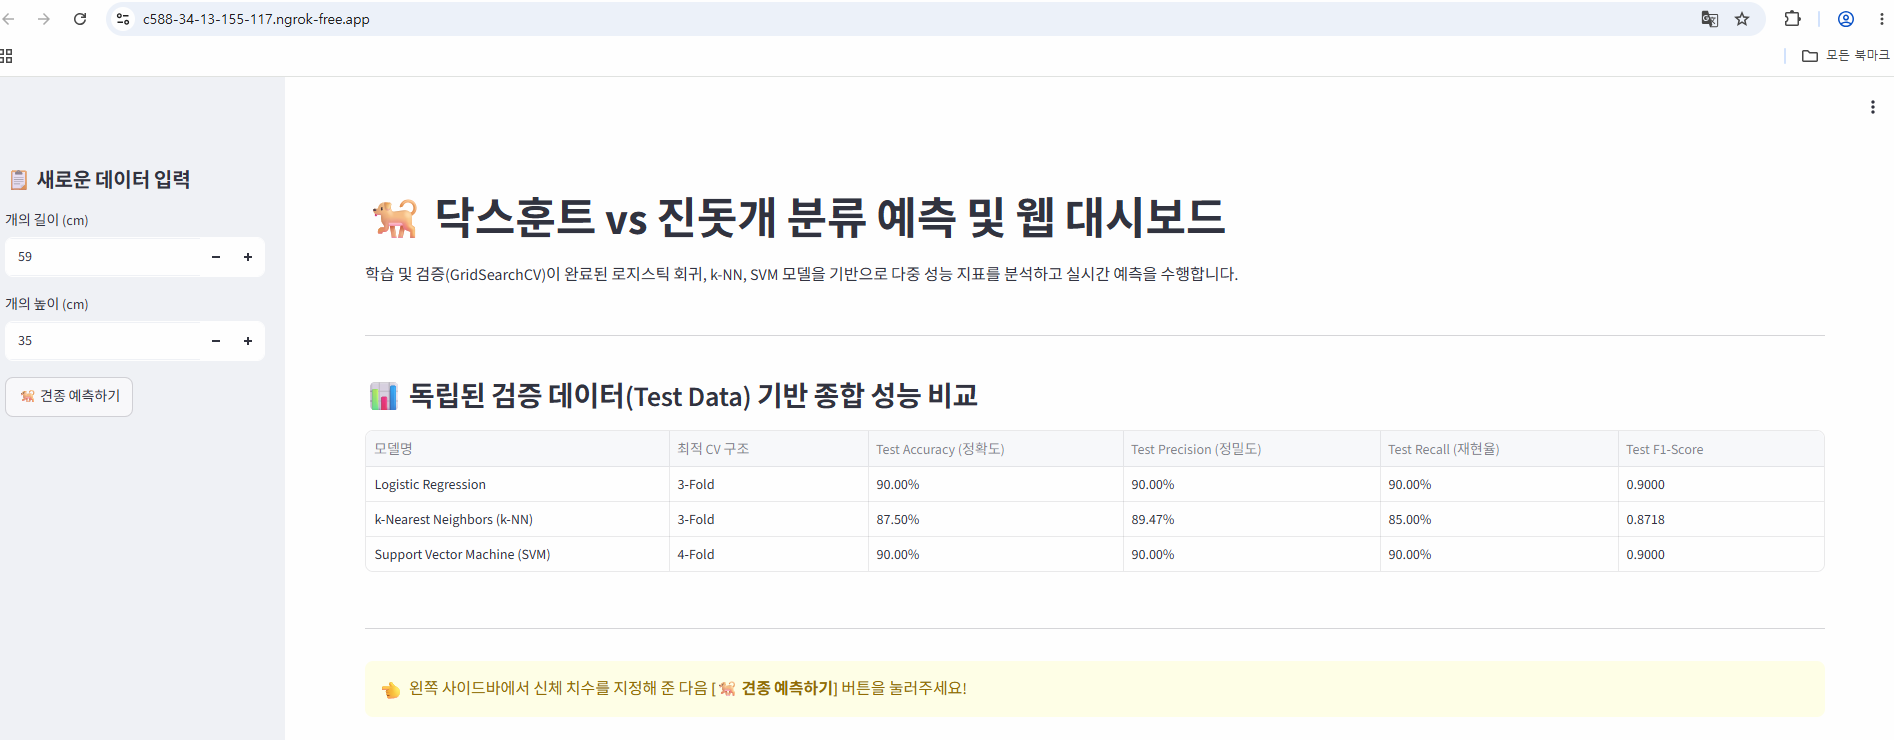

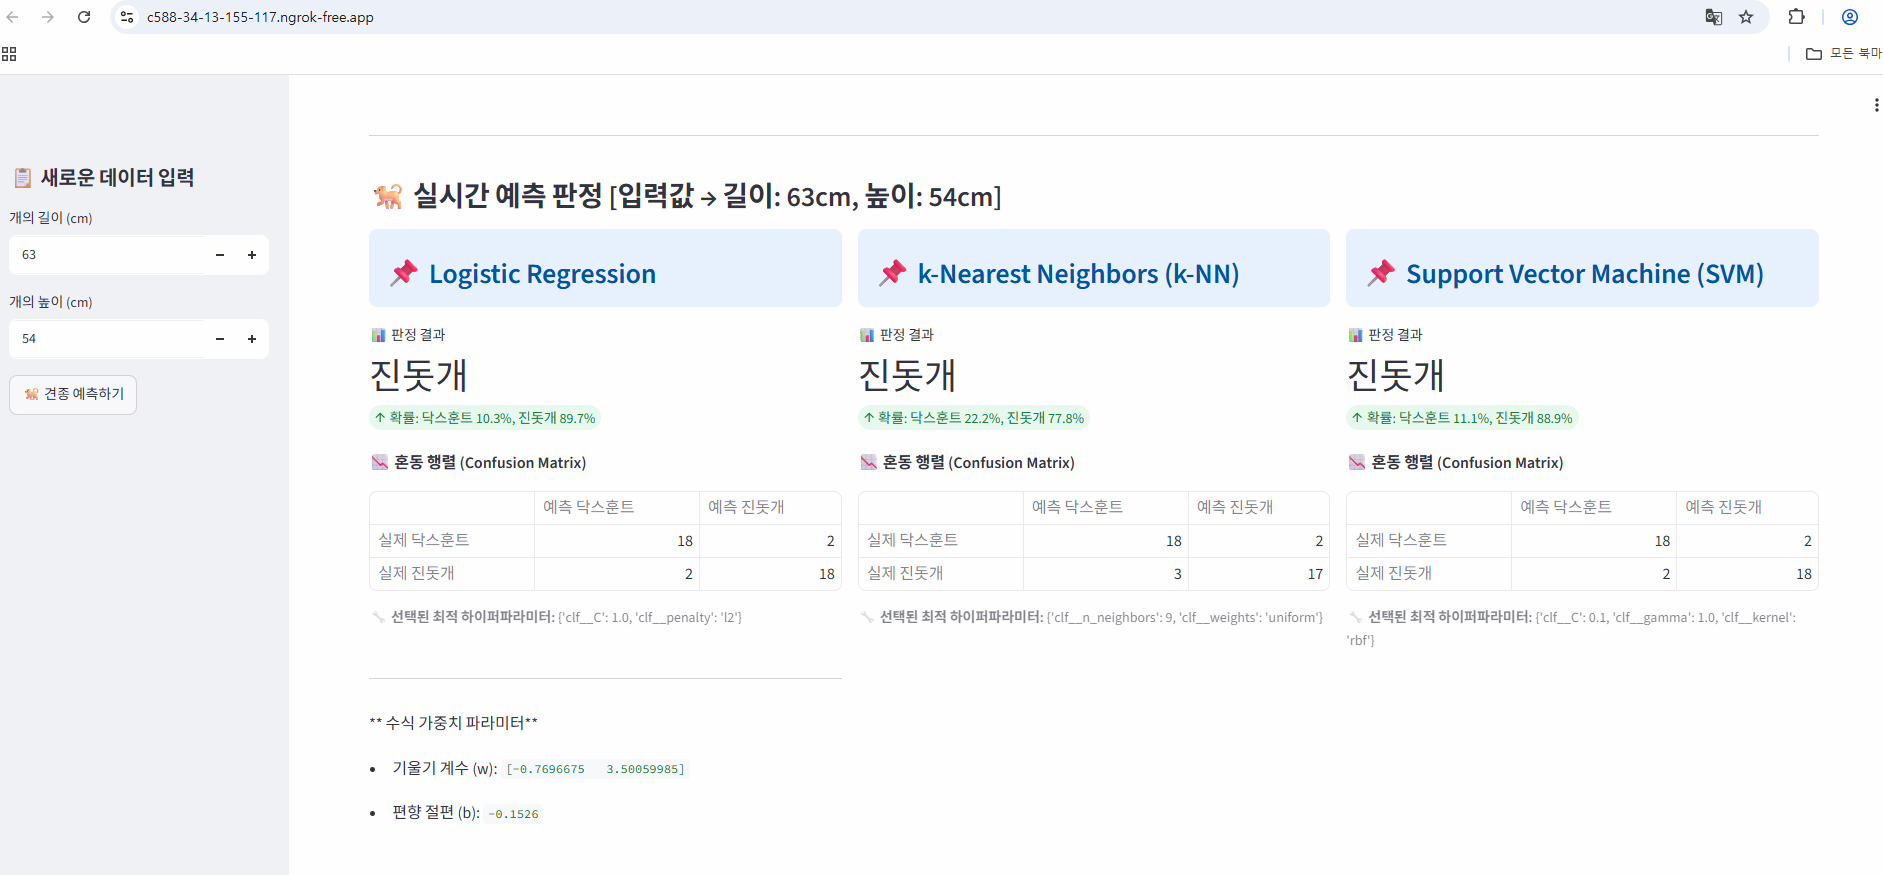